Calculate the HMF. This is the cleaned up version.

In [1]:
import numpy as np
from classy import Class
import astropy.units as u
import zeus21
from scipy.interpolate import RegularGridInterpolator
import matplotlib.ticker as ticker
import cosmo_calc
import hmf
import importlib
import eplots
from scipy import integrate

In [69]:
# Parameters that define the cosmology
Omega_b = 0.04927
Omega_m = 0.3156
h = 0.6727 #H0/100
k_max = 1e3
z = 9

# HMF w/ CLASS
## (from scratch)

In [3]:
# Compute the comsology
cosmo = cosmo_calc.classy_cosmology(Omega_b, Omega_m, h, k_max, z_max = 12)

In [4]:
# Get Zeus HMF class for comparison throughout
params, HMFintclass = cosmo_calc.hmf_zeus(z=z)

Text(0, 0.5, 'P(k) / $Mpc^3$')

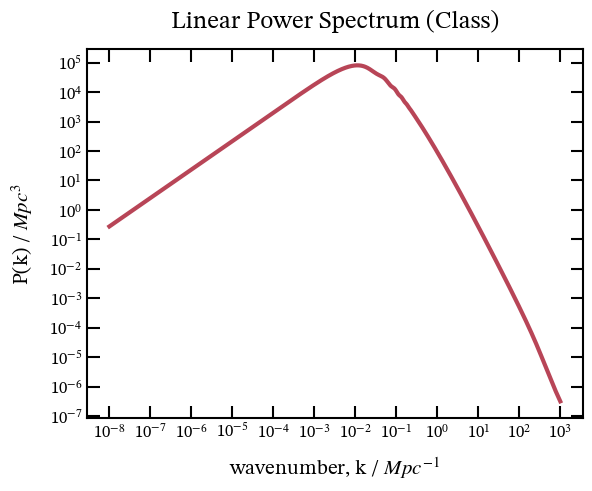

In [5]:
# Plot the linear power spectrum

#Specify k and z
k = np.logspace(-8, 3, num=1000)

# Calculate the linear power spectrum
Plin = np.array([cosmo.pk_lin(ki, z) for ki in k])

# Plot
fig, ax = plt.subplots()
ax.plot(k, Plin)
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_title('Linear Power Spectrum (Class)')
ax.set_xlabel(r'wavenumber, k / $Mpc^{-1}$')
ax.set_ylabel(r'P(k) / $Mpc^3$')

$\sigma^2(R) = \frac{1}{2\pi^2} \int_0^{\infty}k^2P(k)W^2(kR)dk = \langle \delta \rangle$ \
$W(kR) = \frac{3(sin(kR)-kRcos(kR))}{(kR)^3}$

In [6]:
def sigma_integrand(k, R, z):
    """
    Helper function for calc_sigma
    """
    P = cosmo.pk_lin(k, z)
    W = 3*(np.sin(k*R)-(k*R*np.cos(k*R)))/((k*R)**3)
    return (1/(2*np.pi**2))*k**2*P*W**2

In [7]:
def calc_sigma(R, k_range, z=0):
    """
    Calculate mass variance, sigma(R)
    Inputs:
        R [float]: radius [Mpc]
        k_range [1darr]: range of wavenumbers to evaluate over (each in Mpc^-1)
        z [float]: redshift
    Returns:
        sigma(R) [float]: see equation above
    """
    return np.sqrt(np.trapz([sigma_integrand(k, R=R, z=z) for k in k_range], k_range))

In [8]:
# Calculate matter variance, sigma(R) from the equation
R_values = np.logspace(-2, 4, 1000)
sigma = np.zeros_like(R_values)
for i, R in enumerate(R_values):
    sigma[i] = calc_sigma(R, k, z) # Uses the same values of k defined for the matter power spectrum

In [9]:
# For comparison...

# Calculate matter variance with Class
sigma_class = [cosmo.sigma(R, z) for R in R_values]

# Calculate matter variance with Zeus
sigma_zeus = HMFintclass.sigmaR_int(R_values, z)

Text(0.5, 1.0, 'Mass variance, $z=0$')

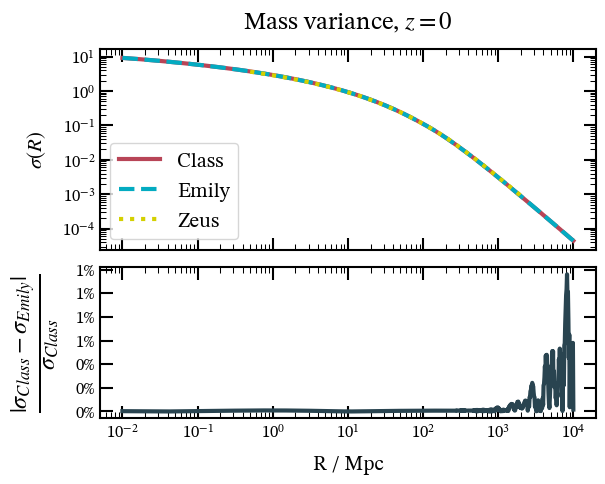

In [10]:
# Plot matter variance
fig, ax = eplots.percent_diff_plot(R_values, sigma_class, sigma, labels = ['Class', 'Emily', 'Zeus'], other_data = [sigma_zeus])

ax[0].set_ylabel(r'$\sigma(R)$')
ax[1].set_xlabel('R / Mpc')
ax[1].set_ylabel(r'$\frac{|\sigma_{Class} - \sigma_{Emily}|}{\sigma_{Class}}$', fontsize = 25)

ax[0].set_title(f'Mass variance, $z={z}$')

# fig.savefig('/Users/eb35267/Desktop/research/figures/sigmaR.png', bbox_inches='tight')

Calculate the HMF with the Press-Schechter fitting function, which defines the fraction of mass collapsed: \
$f_{PS}(\sigma) = \sqrt{\frac{2}{\pi}} \frac{\delta_c}{\sigma} \exp[-\frac{\delta_c^2}{2\sigma^2}]$ \
where $\delta_c = 1.686$ (critical overdensity for spherical collapse) \
or the Sheth-Tormen fitting function: \
$f_{ST}(\sigma) = A \sqrt{\frac{2a}{\pi}}[1+(\frac{\sigma^2}{a\delta_c^2})^p] \exp[-\frac{\delta_c^2}{2\sigma^2}]$

In [11]:
def calc_fPS(sigma, delta_c = 1.686):
    """
    Evaluate the Press-Schechter fitting function
    Inputs:
        sigma [1darray]: mass variance
        delta_c [float]: critical overdensity for spherical collapse
    Returns:
        f(sigma) [1darra]: sqrt(2/pi)*delta_c/sigma*exp(-delta_c^2/2sigma^2)
    """
    return np.sqrt(2/np.pi)*delta_c/sigma*(np.e**(-(delta_c**2)/(2*sigma**2)))

In [12]:
def calc_fST(sigma, delta_c = 1.686, A = 0.3222, a = 0.707, p = 0.3):
    """
    Evaluate the Sheth-Tormen fitting function
    Inputs:
        sigma [1darray]: mass variance
        (delta_c, A, a, p) [floats]: parameters of the Sheth-Tormen fitting function (see above)
    """
    return A*np.sqrt(2*a/np.pi)*(1+(sigma**2/(a*delta_c**2))**p)*(delta_c/sigma)*np.exp(-(a*delta_c**2/(2*sigma**2)))

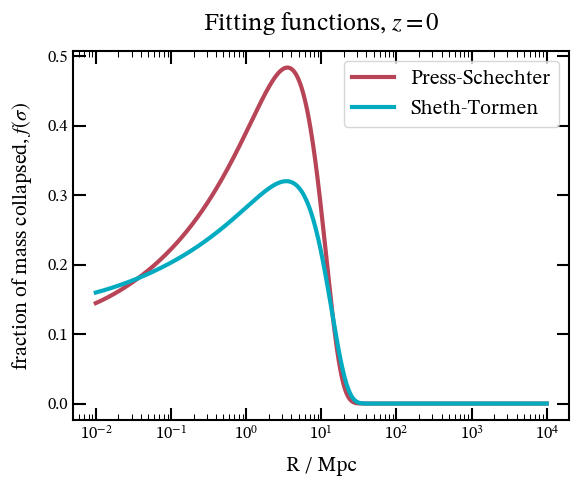

In [13]:
# Calculate & plot Press-Schechter fitting function

fPS = calc_fPS(sigma)
fST = calc_fST(sigma)

fig, ax = plt.subplots()
ax.plot(R_values, fPS, label = 'Press-Schechter')
ax.plot(R_values, fST, label = 'Sheth-Tormen')
ax.set_title(f'Fitting functions, $z={z}$')
ax.set_ylabel(r'fraction of mass collapsed, $f(\sigma)$')
ax.set_xlabel('R / Mpc')
ax.set_xscale('log')
ax.legend()

$\frac{dn}{d\ln M} = M*\frac{\rho_0}{M^2}*f(\sigma)*|\frac{d\ln\sigma}{d\ln M}|$ \
Use $\frac{d\ln\sigma}{d\ln M} = \frac{d\sigma}{dM} * \frac{M}{\sigma}$ \
and where $\rho_0$ is the cosmology-dependent mean MATTER density, $\rho_{M,0}$: \
$\rho_{crit, 0} = \frac{3H_0^2}{8\pi G}$ \
$\rho_{M,0} = \Omega_{M} * \rho_{crit, 0}$ 

In [14]:
def calc_rho_0(cosmo, Omega_tot = 1):
    """
    Calculate the mean density of the universe
    Inputs:
        cosmo: cosmology computed with Class
        Omega_tot [float]: ratio of the total density of the universe to the critical density. This should be 1 if the universe is flat
                           (so most cosmologies)
    Returns:
        rho_0 [float]: mean density of the universe
    """

    # Put constants in the right units to calculate rho_crit = 3H_0**2 / 8*pi*G
    c = 3e8*u.m/u.s # speed of light
    H0 = (cosmo.Hubble(z)/u.Mpc*c).to(u.s**-1) # H0 comes divided by c by default, so we have to take that out
    G = 6.67430e-11* u.m**3 * u.s**-2 * u.kg**-1

    rho_crit_0 = ((3*H0**2)/(8*np.pi*G)).to(u.Msun/u.Mpc**3)

    return (Omega_tot*rho_crit_0).value

In [15]:
def M_to_R (M, rho_0, Omega_m):
    """
    Convert a mass to the radius of a sphere that would enclose that mass given the mean density of the universe.
    Inputs:
        M [float]: mass (M_sun)
        rho_0 [float]: mean density of the universe (M_sun / Mpc^3)
        Omega_m [float]: Omega matter
    Returns:
        R [float]: radius (Mpc) of a sphere that would enclose the given mass. R = (3M/4*pi*rho_0_m)^1/3
    """

    rho_0_m = Omega_m * rho_0 # This is the mean !matter! density of the universe, which is what we're concerned with here

    return (3*M/(4*np.pi*rho_0_m))**(1/3)

In [16]:
def calc_sigmaM(M_vals, rho_0, Omega_m, k, z = 0):
    """
    Calculate the mass variance as a function of masses instead of radii
    Inputs:
        M_vals [1darr]: mass range for evalutation (M_sun)
        rho_0 [float]: mean density of the universe (M_sun / Mpc^3)
        Omega_m [float]: Omega matter
        k [1darray]: range of wavenumbers to evaluate the mass variance (each one has units Mpc^-1)
        z [float]: redshift
    Returns:
        sigma(M) [1darray]: mass variance for each input M_val
    """

    R_vals = [M_to_R(M, rho_0, Omega_m) for M in M_vals]

    return np.array([calc_sigma(R, k, z) for R in R_vals])

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_38675/1917046321.py:11: SyntaxWarning: invalid escape sequence '\s'
  ax[0].set_title(f'Comparing $\sigma(M), z={z}$')


Text(0.5, 0, 'Mass / $M_{\\odot}$')

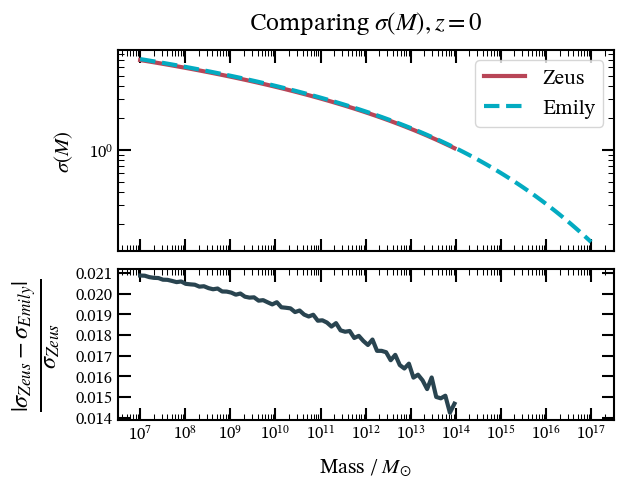

In [17]:
# Calculate sigma(M)
rho_0 = calc_rho_0(cosmo)
M_vals = np.logspace(7, 17, 100)
sigmaM = calc_sigmaM(M_vals, rho_0, Omega_m, k, z)

# Calculate sigma(M) with Zeus
sigmaM_zeus = HMFintclass.sigma_int(M_vals, z)

# Plot difference
fig, ax = eplots.percent_diff_plot(M_vals, sigmaM_zeus, sigmaM, labels = ['Zeus', 'Emily'])
ax[0].set_title(f'Comparing $\sigma(M), z={z}$')
ax[0].set_ylabel(r'$\sigma(M)$')
ax[1].set_yscale('linear')
ax[1].set_ylabel(r'$\frac{|\sigma_{Zeus} - \sigma_{Emily}|}{\sigma_{Zeus}}$', fontsize = 25)
ax[1].set_xlabel(r'Mass / $M_{\odot}$')

#fig.savefig('/Users/eb35267/Desktop/research/figures/sigma_M_comparison.png', bbox_inches='tight')

In [18]:
# fig, ax = plt.subplots()
# ax.plot(M_vals, M_to_R(M_vals, rho_0, Omega_m), color = '#111114')
# ax.set_xlabel(r'Mass / $M_\odot$')
# ax.set_ylabel('Radius / Mpc')
# ax.set_xscale('log')
# ax.set_yscale('log')
# ax.axvline(x=1e10, label = r'$M = 10^{10} M_\odot$', linestyle = '--', color = '#111114')
# ax.legend()

# fig.savefig('/Users/eb35267/Desktop/research/figures/r_vs_m.png', bbox_inches='tight')

Text(0.5, 0, 'Mass / $M_{\\odot}$')

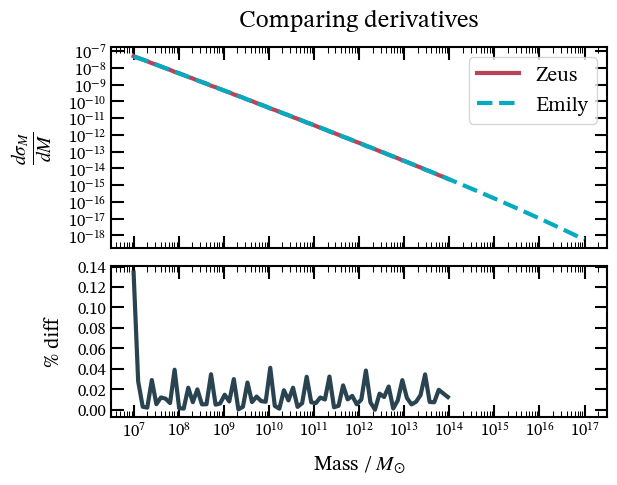

In [19]:
sigma_deriv = np.abs(np.gradient(sigmaM, M_vals))

# Calculate the derivative with Zeus
sigma_deriv_zeus = np.abs(HMFintclass.dsigmadM_int(M_vals, z))

# Compare
fig, ax = eplots.percent_diff_plot(M_vals, sigma_deriv_zeus, sigma_deriv, labels = ['Zeus', 'Emily'])

ax[0].set_title('Comparing derivatives')
ax[0].set_ylabel(r'$\frac{d\sigma_M}{dM}$', fontsize = 20)
ax[1].set_yscale('linear')
ax[1].set_ylabel('% diff')
ax[1].set_xlabel(r'Mass / $M_{\odot}$')

# fig.savefig('/Users/eb35267/Desktop/research/figures/dsigmadM_problem.png', bbox_inches='tight')

In [20]:
def calc_HMF_ST(M_vals, k, cosmo, z = 0):
    """
    Calcule dn/dlnM
    Inputs: 
        M_vals [1darr]: mass range for evalutation (M_sun)
        k [1darray]: range of wavenumbers to evaluate the mass variance (each one has units Mpc^-1)
        cosmo [Class object]: computed cosmology
    Returns:
        dn/dlnM
    """
    Omega_m = cosmo.pars['Omega_b'] + cosmo.pars['Omega_cdm']
    rho_0 = calc_rho_0(cosmo)

    sigmaM= calc_sigmaM(M_vals, rho_0, Omega_m, k, z)
    fST = calc_fST(sigmaM)
    sigmaM_deriv = np.gradient(sigmaM, M_vals) # This is dsigma/dM

    rho_0M = rho_0 * Omega_m

    return rho_0M/sigmaM * fST * np.abs(sigmaM_deriv) # See notes from January 15th where I show this is the same as the version given in 
                                                     # the book

/Users/eb35267/Desktop/research/escripts/eplots.py:54: RuntimeWarning: divide by zero encountered in divide
  percent_diff = np.abs(y1-y0) / y0


Text(0.5, 1.0, 'Comparing ST HMF, $z=0$')

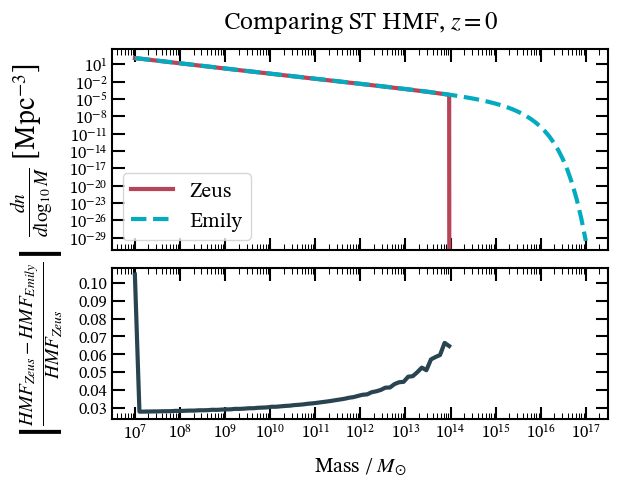

In [21]:
HMF_ST_eq = calc_HMF_ST(M_vals, k, cosmo) # This is dn/dlnM
HMF_ST_Zeus = HMFintclass.HMF_int(M_vals, z=0) * M_vals # HMF from Zeus is given as dn/dM, so we multiply by M to make it dn/dlnM (see notes
                                                        # from January 4th where I prove this)


fig, ax = eplots.percent_diff_plot(M_vals, HMF_ST_Zeus*np.log(10), HMF_ST_eq*np.log(10), labels = ['Zeus', 'Emily']) 
                                                                  # Convert to dn/dlog10M for comparison with Bullock & Boylan-Kolchin, 2017
                                                        # See notes from January 15th where I show why we multiply by ln(10) to achieve this

ax[0].set_ylabel(r'$\frac{dn}{d\log_{10}M}$ [Mpc$^{-3}$]', fontsize = 20)
ax[1].set_ylabel(r'$\left|\frac{HMF_{Zeus} - HMF_{Emily}}{HMF_{Zeus}}\right|$', fontsize = 20)
ax[1].set_yscale('linear')
ax[1].set_xlabel(r'Mass / $M_{\odot}$')
ax[0].set_title(f'Comparing ST HMF, $z={z}$')

#fig.savefig('/Users/eb35267/Desktop/research/figures/hmf.png', bbox_inches='tight')

# HMF w/ Zeus

In [70]:
hmf_comp = hmf.hmf.MassFunction(Mmin = 5, Mmax = 14, dlog10m = .1, hmf_model = 'ST', z = z)
input_mass = hmf_comp.m/h # HMF default is mass in M_sun/h, so you divide by your value of h to get M_sun

In [71]:
hmf_zeus = HMFintclass.HMF_int(input_mass, z)

In [72]:
HMF_ST_eq = calc_HMF_ST(input_mass, k, cosmo, z)/input_mass # This is dn/dlnM by default, so we divide by M to make it dn/dM

Text(0.5, 1.0, 'HMF at $z=9$')

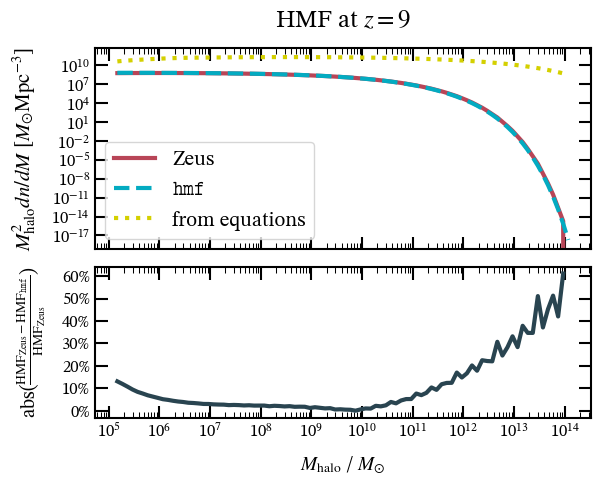

In [73]:
fig, axs = eplots.percent_diff_plot(input_mass, y0 = hmf_zeus*input_mass**2,y1 = (hmf_comp.dndm*h**(4))*input_mass**2, 
                            labels = ['Zeus', r'$\tt{hmf}$', 'from equations'], other_data = [HMF_ST_eq*input_mass**2])
axs[0].set_ylabel(r'$M_{\rm{halo}}^2 dn/dM$ [$M_{\odot}\rm{Mpc}^{-3}$]')
axs[1].set_xlabel(r'$M_{\rm{halo}}$ / $M_{\odot}$', fontsize = 14)
axs[1].set_ylabel(r'abs($\frac{\rm{HMF}_{\rm{Zeus}} - \rm{HMF}_{\tt{hmf}}}{\rm{HMF}_{\rm{Zeus}}}$)', fontsize = 14)
axs[0].set_title(f'HMF at $z={z}$')

#fig.savefig('/Users/eb35267/Desktop/figures/problems/hmf_comparison.png', bbox_inches = 'tight')

# Trying the cumulative HMF

In [74]:
add = np.trapz(HMFintclass.HMF_int(np.logspace(14, 19, 100), z), np.logspace(14, 19, 100)) # Add on the cumulative up to 10^18
zeus_chmf = (-integrate.cumulative_trapezoid(hmf_zeus[::-1], input_mass[::-1]) + add)[::-1]

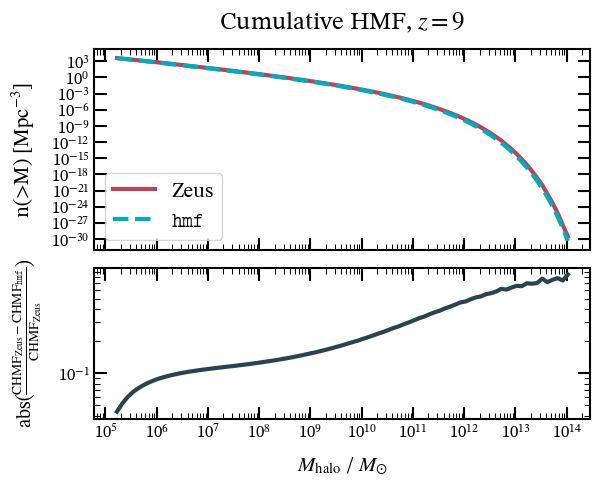

In [75]:
avg_mass = (input_mass[1:]+input_mass[:-1])/2
avg_chmf = ((hmf_comp.ngtm*h**3)[1:] + (hmf_comp.ngtm*h**3)[:-1]) / 2
fig, ax = eplots.percent_diff_plot(avg_mass, zeus_chmf, avg_chmf, labels = ['Zeus', r'$\tt{hmf}$'])
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_ylabel(r'n(>M) [$\rm{Mpc}^{-3}$]')
ax[1].set_xlabel(r'$M_{\rm{halo}}$ / $M_{\odot}$')
ax[0].set_title(f'Cumulative HMF, $z={z}$')
ax[1].set_ylabel(r'abs($\frac{\rm{CHMF}_{\rm{Zeus}} - \rm{CHMF}_{\tt{hmf}}}{\rm{CHMF}_{\rm{Zeus}}}$)', fontsize = 14)
ax[1].set_yscale('log')

#fig.savefig('/Users/eb35267/Desktop/figures/problems/chmf.png', bbox_inches = 'tight')

In [76]:
params, test_hmf = cosmo_calc.hmf_zeus(z=z)
test = test_hmf.HMF_int(input_mass, z)

Text(0.5, 1.0, 'HMF at $z=9$')

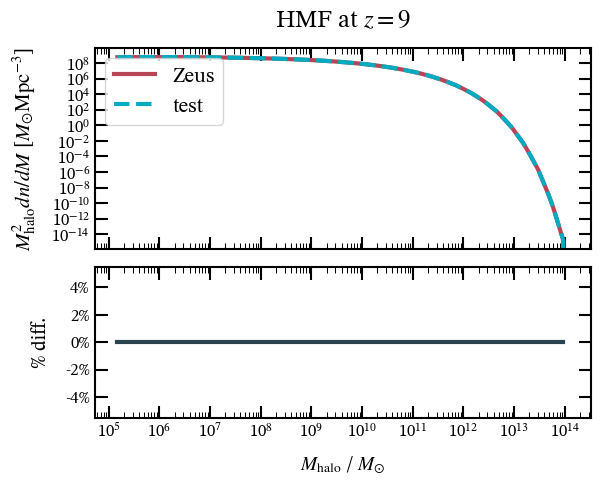

In [77]:
fig, axs = eplots.percent_diff_plot(input_mass, y0 = hmf_zeus*input_mass**2, y1 = test*input_mass**2, labels = ['Zeus', 'test'])
axs[0].set_ylabel(r'$M_{\rm{halo}}^2 dn/dM$ [$M_{\odot}\rm{Mpc}^{-3}$]')
axs[1].set_xlabel(r'$M_{\rm{halo}}$ / $M_{\odot}$', fontsize = 14)
axs[1].set_ylabel(r'% diff.', fontsize = 14)
axs[0].set_title(f'HMF at $z={z}$')

In [41]:
input_mass

array([1.48654675e+05, 1.87145148e+05, 2.35601783e+05, 2.96605071e+05,
       3.73403662e+05, 4.70087358e+05, 5.91804921e+05, 7.45038254e+05,
       9.37947591e+05, 1.18080606e+06, 1.48654675e+06, 1.87145148e+06,
       2.35601783e+06, 2.96605071e+06, 3.73403662e+06, 4.70087358e+06,
       5.91804921e+06, 7.45038254e+06, 9.37947591e+06, 1.18080606e+07,
       1.48654675e+07, 1.87145148e+07, 2.35601783e+07, 2.96605071e+07,
       3.73403662e+07, 4.70087358e+07, 5.91804921e+07, 7.45038254e+07,
       9.37947591e+07, 1.18080606e+08, 1.48654675e+08, 1.87145148e+08,
       2.35601783e+08, 2.96605071e+08, 3.73403662e+08, 4.70087358e+08,
       5.91804921e+08, 7.45038254e+08, 9.37947591e+08, 1.18080606e+09,
       1.48654675e+09, 1.87145148e+09, 2.35601783e+09, 2.96605071e+09,
       3.73403662e+09, 4.70087358e+09, 5.91804921e+09, 7.45038254e+09,
       9.37947591e+09, 1.18080606e+10, 1.48654675e+10, 1.87145148e+10,
       2.35601783e+10, 2.96605071e+10, 3.73403662e+10, 4.70087358e+10,
      